In [1]:
import copy
import io
import random
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from torch.ao.quantization import (
    DeQuantStub,
    QuantStub,
    convert,
    fuse_modules,
    get_default_qat_qconfig,
    prepare_qat,
    quantize_dynamic,
)

# Suppress known quantization deprecation noise so notebook outputs remain readable.
warnings.filterwarnings("ignore", category=DeprecationWarning, module=r"torch\.ao\.quantization")
warnings.filterwarnings("ignore", message=r".*torch\.ao\.quantization is deprecated.*")
warnings.filterwarnings("ignore", message=r".*reduce_range will be deprecated.*")

# Optional torchao INT4 branch (best-effort)
TORCHAO_AVAILABLE = False
torchao_import_error = None
try:
    from torchao.quantization import quantize_, Int4WeightOnlyConfig
    TORCHAO_AVAILABLE = True
except Exception as e:
    torchao_import_error = str(e)
    warnings.warn(f"torchao INT4 branch unavailable: {e}")

W0328 15:29:29.463000 35928 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [2]:
SEED = 42
DATASET_NAME = "compas"  # "compas" or "german"
BATCH_SIZE = 64
BASE_EPOCHS = 25
QAT_FINETUNE_EPOCHS = 10
LR = 1e-3
REC_N_SAMPLES = 80
DECISION_THRESHOLD = 0.5

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Keep the experiment on CPU for quantization compatibility and reproducibility.
device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
def load_preprocess_dataset(dataset_name: str):
    if dataset_name.lower() == "compas":
        df = pd.read_csv("data/compas_carla.csv")
        target_col = "score"
    elif dataset_name.lower() == "german":
        df = pd.read_csv("data/german.csv")
        target_col = "credit_risk"
    else:
        raise ValueError("dataset_name must be 'compas' or 'german'.")

    y = df[target_col].astype(int).copy()
    X = df.drop(columns=[target_col]).copy()

    num_cols = X.select_dtypes(include=[np.number]).columns
    cat_cols = X.select_dtypes(include=["object", "category"]).columns

    scaler = StandardScaler()
    if len(num_cols) > 0:
        X[num_cols] = scaler.fit_transform(X[num_cols])

    X = pd.get_dummies(X, columns=cat_cols, dtype=float)
    X = X.astype(np.float32)

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=0.20, random_state=SEED, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=0.20,
        random_state=SEED,
        stratify=y_train_full,
    )

    data = {
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "feature_names": list(X.columns),
        "feature_min": X_train.min(axis=0).to_numpy(dtype=np.float32),
        "feature_max": X_train.max(axis=0).to_numpy(dtype=np.float32),
    }
    return data

data = load_preprocess_dataset(DATASET_NAME)
for k in ["X_train", "X_val", "X_test"]:
    print(f"{k}: {data[k].shape}")

X_train: (3949, 10)
X_val: (988, 10)
X_test: (1235, 10)


In [5]:
class MLPBinary(nn.Module):
    def __init__(self, input_dim: int, hidden_dims=(64, 32)):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dims[0])
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_dims[1], 1)
        self.sigmoid = nn.Sigmoid()

    def _forward_prob1_tensor(self, x: torch.Tensor) -> torch.Tensor:
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        p1 = self.sigmoid(self.fc3(x)).squeeze(-1)
        return p1

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        p1 = self._forward_prob1_tensor(x)
        p0 = 1.0 - p1
        return torch.stack([p0, p1], dim=1)

    @staticmethod
    def _to_tensor(x):
        if isinstance(x, torch.Tensor):
            return x.float(), True
        return torch.tensor(np.asarray(x), dtype=torch.float32), False

    def predict_prob_1(self, x):
        xt, is_tensor = self._to_tensor(x)
        self.eval()
        with torch.no_grad():
            out = self._forward_prob1_tensor(xt)
        return out if is_tensor else out.cpu().numpy()

    def predict_proba(self, x):
        xt, is_tensor = self._to_tensor(x)
        self.eval()
        with torch.no_grad():
            out = self.forward(xt)
        return out if is_tensor else out.cpu().numpy()

    def predict_labels(self, x):
        probs = self.predict_proba(x)
        if isinstance(probs, np.ndarray):
            y1 = (probs[:, 1] >= DECISION_THRESHOLD).astype(np.float32)
            y0 = 1.0 - y1
            return np.stack([y0, y1], axis=1)
        y1 = (probs[:, 1] >= DECISION_THRESHOLD).float()
        y0 = 1.0 - y1
        return torch.stack([y0, y1], dim=1)

    # Backward-compatible alias used by existing ROAR calls.
    def predict_both_labels(self, x):
        return self.predict_labels(x)


class QuantizableMLPBinary(nn.Module):
    def __init__(self, input_dim: int, hidden_dims=(64, 32)):
        super().__init__()
        self.quant = QuantStub()
        self.fc1 = nn.Linear(input_dim, hidden_dims[0])
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_dims[1], 1)
        self.sigmoid = nn.Sigmoid()
        self.dequant = DeQuantStub()

    def fuse_model(self):
        fuse_modules(self, [["fc1", "relu1"], ["fc2", "relu2"]], inplace=True)

    def _forward_prob1_tensor(self, x: torch.Tensor) -> torch.Tensor:
        x = self.quant(x)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        x = self.sigmoid(x)
        x = self.dequant(x)
        return x.squeeze(-1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        p1 = self._forward_prob1_tensor(x)
        p0 = 1.0 - p1
        return torch.stack([p0, p1], dim=1)

    @staticmethod
    def _to_tensor(x):
        if isinstance(x, torch.Tensor):
            return x.float(), True
        return torch.tensor(np.asarray(x), dtype=torch.float32), False

    def predict_prob_1(self, x):
        xt, is_tensor = self._to_tensor(x)
        self.eval()
        with torch.no_grad():
            out = self._forward_prob1_tensor(xt)
        return out if is_tensor else out.cpu().numpy()

    def predict_proba(self, x):
        xt, is_tensor = self._to_tensor(x)
        self.eval()
        with torch.no_grad():
            out = self.forward(xt)
        return out if is_tensor else out.cpu().numpy()

    def predict_labels(self, x):
        probs = self.predict_proba(x)
        if isinstance(probs, np.ndarray):
            y1 = (probs[:, 1] >= DECISION_THRESHOLD).astype(np.float32)
            y0 = 1.0 - y1
            return np.stack([y0, y1], axis=1)
        y1 = (probs[:, 1] >= DECISION_THRESHOLD).float()
        y0 = 1.0 - y1
        return torch.stack([y0, y1], dim=1)

    def predict_both_labels(self, x):
        return self.predict_labels(x)

In [6]:
@dataclass
class Metrics:
    loss: float
    accuracy: float
    auroc: float


def evaluate_model(model, X_tensor, y_tensor, criterion):
    model.eval()
    with torch.no_grad():
        probs_2 = model(X_tensor)
        probs_1 = probs_2[:, 1]
        loss = criterion(probs_1, y_tensor).item()
        probs = probs_1.cpu().numpy()
        y_true = (y_tensor.cpu().numpy() >= DECISION_THRESHOLD).astype(np.int32)
        y_pred = (probs >= DECISION_THRESHOLD).astype(np.int32)
        acc = accuracy_score(y_true, y_pred)
        try:
            auc = roc_auc_score(y_true, probs)
        except ValueError:
            auc = float("nan")
    return Metrics(loss=loss, accuracy=acc, auroc=auc)


def train_model(model, train_loader, X_val, y_val, epochs=20, lr=1e-3):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()
    for epoch in range(epochs):
        for xb, yb in train_loader:
            optimizer.zero_grad()
            probs_1 = model(xb)[:, 1]
            loss = criterion(probs_1, yb)
            loss.backward()
            optimizer.step()
        if (epoch + 1) % 5 == 0 or epoch == epochs - 1:
            m = evaluate_model(model, X_val, y_val, criterion)
            print(
                f"Epoch {epoch+1:>2}/{epochs} | val_loss={m.loss:.4f} "
                f"| val_acc={100*m.accuracy:.2f}% | val_auc={m.auroc:.4f}"
            )
    return model


def model_size_kb(model):
    buffer = io.BytesIO()
    torch.save(model.state_dict(), buffer)
    return len(buffer.getvalue()) / 1024.0

In [7]:
X_train_tensor = torch.tensor(data["X_train"].to_numpy(), dtype=torch.float32, device=device)
y_train_tensor = torch.tensor(data["y_train"].to_numpy(), dtype=torch.float32, device=device)
X_val_tensor = torch.tensor(data["X_val"].to_numpy(), dtype=torch.float32, device=device)
y_val_tensor = torch.tensor(data["y_val"].to_numpy(), dtype=torch.float32, device=device)
X_test_tensor = torch.tensor(data["X_test"].to_numpy(), dtype=torch.float32, device=device)
y_test_tensor = torch.tensor(data["y_test"].to_numpy(), dtype=torch.float32, device=device)

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
)

input_dim = X_train_tensor.shape[1]
print(f"Input dimension: {input_dim}")

base_model = MLPBinary(input_dim=input_dim).to(device)
base_model = train_model(base_model, train_loader, X_val_tensor, y_val_tensor, epochs=BASE_EPOCHS, lr=LR)

criterion_eval = nn.BCELoss()
base_metrics = evaluate_model(base_model, X_test_tensor, y_test_tensor, criterion_eval)
print(
    f"FP32 Base | loss={base_metrics.loss:.4f} "
    f"| acc={100*base_metrics.accuracy:.2f}% | auc={base_metrics.auroc:.4f}"
)

Input dimension: 10
Epoch  5/25 | val_loss=0.3464 | val_acc=84.31% | val_auc=0.8518
Epoch 10/25 | val_loss=0.3443 | val_acc=84.01% | val_auc=0.8551
Epoch 15/25 | val_loss=0.3415 | val_acc=84.11% | val_auc=0.8574
Epoch 20/25 | val_loss=0.3397 | val_acc=83.91% | val_auc=0.8594
Epoch 25/25 | val_loss=0.3398 | val_acc=83.91% | val_auc=0.8604
FP32 Base | loss=0.3599 | acc=83.89% | auc=0.8349


In [8]:
# INT8 PTQ (dynamic quantization: weight INT8 for nn.Linear)
ptq_source_model = copy.deepcopy(base_model).cpu().eval()
ptq_int8_model = quantize_dynamic(
    ptq_source_model,
    {nn.Linear},
    dtype=torch.qint8,
 )

ptq_metrics = evaluate_model(ptq_int8_model, X_test_tensor.cpu(), y_test_tensor.cpu(), criterion_eval)
print(
    f"INT8 PTQ | loss={ptq_metrics.loss:.4f} "
    f"| acc={100*ptq_metrics.accuracy:.2f}% | auc={ptq_metrics.auroc:.4f}"
)

INT8 PTQ | loss=0.3595 | acc=83.97% | auc=0.8355


In [9]:
# INT8 QAT (eager mode)
qat_float_model = QuantizableMLPBinary(input_dim=input_dim).cpu()
qat_float_model.load_state_dict(copy.deepcopy(base_model).cpu().state_dict(), strict=True)
qat_float_model.fuse_model()
qat_float_model.qconfig = get_default_qat_qconfig("fbgemm")
prepare_qat(qat_float_model, inplace=True)

qat_optimizer = optim.Adam(qat_float_model.parameters(), lr=LR * 0.5)
qat_criterion = nn.BCELoss()
qat_float_model.train()

for epoch in range(QAT_FINETUNE_EPOCHS):
    for xb, yb in train_loader:
        xb = xb.cpu()
        yb = yb.cpu()
        qat_optimizer.zero_grad()
        probs_1 = qat_float_model(xb)[:, 1]
        loss = qat_criterion(probs_1, yb)
        loss.backward()
        qat_optimizer.step()
    if (epoch + 1) % 5 == 0 or epoch == QAT_FINETUNE_EPOCHS - 1:
        m = evaluate_model(qat_float_model, X_val_tensor.cpu(), y_val_tensor.cpu(), qat_criterion)
        print(
            f"QAT finetune {epoch+1:>2}/{QAT_FINETUNE_EPOCHS} "
            f"| val_loss={m.loss:.4f} | val_acc={100*m.accuracy:.2f}%"
        )

qat_float_model.eval()
qat_int8_model = copy.deepcopy(qat_float_model)
convert(qat_int8_model, inplace=True)

qat_metrics = evaluate_model(qat_int8_model, X_test_tensor.cpu(), y_test_tensor.cpu(), criterion_eval)
print(
    f"INT8 QAT | loss={qat_metrics.loss:.4f} "
    f"| acc={100*qat_metrics.accuracy:.2f}% | auc={qat_metrics.auroc:.4f}"
)

QAT finetune  5/10 | val_loss=0.3379 | val_acc=84.11%
QAT finetune 10/10 | val_loss=0.3372 | val_acc=84.01%
INT8 QAT | loss=0.3603 | acc=83.72% | auc=0.8349


In [10]:
# Optional INT4 branch (best-effort, non-blocking)
int4_model = None
int4_status = "skipped"
int4_error = None

if TORCHAO_AVAILABLE:
    try:
        int4_model = copy.deepcopy(base_model).cpu().eval()
        quantize_(int4_model, Int4WeightOnlyConfig(group_size=32))
        int4_status = "ok"
        print("INT4 PTQ branch completed.")
    except Exception as e:
        int4_error = str(e)
        int4_status = "failed"
        print(f"INT4 branch failed: {e}")
else:
    print(f"INT4 branch unavailable: {torchao_import_error}")

INT4 branch failed: Requires mslk >= 1.0.0


In [11]:
results_models = [
    {
        "model": "FP32 base",
        "test_acc": base_metrics.accuracy,
        "test_auc": base_metrics.auroc,
        "size_kb": model_size_kb(base_model.cpu()),
    },
    {
        "model": "INT8 PTQ",
        "test_acc": ptq_metrics.accuracy,
        "test_auc": ptq_metrics.auroc,
        "size_kb": model_size_kb(ptq_int8_model),
    },
    {
        "model": "INT8 QAT",
        "test_acc": qat_metrics.accuracy,
        "test_auc": qat_metrics.auroc,
        "size_kb": model_size_kb(qat_int8_model),
    },
]

if int4_model is not None and int4_status == "ok":
    int4_metrics = evaluate_model(int4_model, X_test_tensor.cpu(), y_test_tensor.cpu(), criterion_eval)
    results_models.append(
        {
            "model": "INT4 PTQ (optional)",
            "test_acc": int4_metrics.accuracy,
            "test_auc": int4_metrics.auroc,
            "size_kb": model_size_kb(int4_model),
        }
    )

model_table = pd.DataFrame(results_models)
model_table["acc_delta_vs_base"] = model_table["test_acc"] - model_table.loc[0, "test_acc"]
model_table["size_reduction_vs_base"] = 1.0 - (model_table["size_kb"] / model_table.loc[0, "size_kb"])
model_table

,model,test_acc,test_auc,size_kb,acc_delta_vs_base,size_reduction_vs_base
0,FP32 base,0.838866,0.834897,13.645508,0.000000,0.000000
1,INT8 PTQ,0.839676,0.835489,7.624023,0.000810,0.441280
2,INT8 QAT,0.837247,0.834925,11.100586,-0.001619,0.186503


In [12]:
from methods.probe import PROBE

In [41]:
# Select negatives under the FP32 base model
base_model.eval()
with torch.no_grad():
    test_probs_base = base_model(X_test_tensor)[:, 1].cpu().numpy()

neg_indices = np.where(test_probs_base < DECISION_THRESHOLD)[0]
n_use = min(REC_N_SAMPLES, len(neg_indices))
selected_idx = neg_indices[:n_use]
print(f"Generating recourse for {n_use} negative test instances.")

probe = PROBE()

generated = []
for idx in selected_idx:
    x0 = data["X_test"].iloc[idx].to_numpy(dtype=np.float32)
    x_cf = probe.get_recourse(base_model, x0.reshape(1, -1))
    xcf_t = torch.tensor(x_cf, dtype=torch.float32).reshape(1, -1)
    with torch.no_grad():
        base_prob = base_model(xcf_t)[:, 1].item()
    generated.append(
        {
            "idx": int(idx),
            "x0": x0,
            "xcf": x_cf,
            "base_prob_cf": base_prob,
            "base_ir_cf": np.nan,
            "l1_cost": float(np.linalg.norm(x_cf - x0, ord=1)),
        }
    )

print(f"Generated {len(generated)} counterfactuals.")

Generating recourse for 80 negative test instances.
Generated 80 counterfactuals.


In [42]:
future_models = {
    "INT8 PTQ": ptq_int8_model,
    "INT8 QAT": qat_int8_model,
}
if int4_model is not None and int4_status == "ok":
    future_models["INT4 PTQ (optional)"] = int4_model

rows = []
for item in generated:
    xcf_t = torch.tensor(item["xcf"], dtype=torch.float32).reshape(1, -1)
    with torch.no_grad():
        base_prob = base_model(xcf_t)[:, 1].item()

    record = {
        "idx": item["idx"],
        "l1_cost": item["l1_cost"],
        "base_prob_cf": base_prob,
        "base_valid": float(base_prob >= DECISION_THRESHOLD),
    }

    for name, model in future_models.items():
        with torch.no_grad():
            p = model(xcf_t.cpu())[:, 1].item()
        record[f"{name}_prob_cf"] = p
        record[f"{name}_valid"] = float(p >= DECISION_THRESHOLD)
        record[f"{name}_margin_shift"] = p - base_prob

    rows.append(record)

recourse_transfer_df = pd.DataFrame(rows)
recourse_transfer_df.head()

,idx,l1_cost,base_prob_cf,base_valid,INT8 PTQ_prob_cf,INT8 PTQ_valid,INT8 PTQ_margin_shift,INT8 QAT_prob_cf,INT8 QAT_valid,INT8 QAT_margin_shift
0,15,2.168509,0.554205,1.0,0.554448,1.0,0.000243,0.613281,1.0,0.059076
1,19,0.386409,0.544897,1.0,0.551092,1.0,0.006195,0.597656,1.0,0.052760
2,30,2.121370,0.561869,1.0,0.558476,1.0,-0.003393,0.613281,1.0,0.051412
3,33,0.700533,0.545007,1.0,0.548130,1.0,0.003124,0.582031,1.0,0.037024
4,36,0.527996,0.543730,1.0,0.543866,1.0,0.000136,0.628906,1.0,0.085176


In [43]:
summary_rows = []
base_valid_rate = recourse_transfer_df["base_valid"].mean() if len(recourse_transfer_df) else np.nan
summary_rows.append({"model": "FP32 base", "recourse_validity_rate": base_valid_rate})

for name in future_models.keys():
    valid_col = f"{name}_valid"
    if valid_col in recourse_transfer_df.columns:
        validity = recourse_transfer_df[valid_col].mean()
        invalidation = 1.0 - validity
        summary_rows.append(
            {
                "model": name,
                "recourse_validity_rate": validity,
                "recourse_invalidation_rate": invalidation,
                "delta_vs_base": validity - base_valid_rate,
            }
        )

recourse_summary = pd.DataFrame(summary_rows)

print("Model performance and compression summary")
display(model_table)

print("Recourse transfer summary (base recourse replayed on future models)")
display(recourse_summary)

print(f"INT4 branch status: {int4_status}")
if int4_error is not None:
    print(f"INT4 error: {int4_error}")

Model performance and compression summary


,model,test_acc,test_auc,size_kb,acc_delta_vs_base,size_reduction_vs_base
0,FP32 base,0.838866,0.834897,13.645508,0.000000,0.000000
1,INT8 PTQ,0.839676,0.835489,7.624023,0.000810,0.441280
2,INT8 QAT,0.837247,0.834925,11.100586,-0.001619,0.186503


Recourse transfer summary (base recourse replayed on future models)


,model,recourse_validity_rate,recourse_invalidation_rate,delta_vs_base
0,FP32 base,1.0,NaN,NaN
1,INT8 PTQ,1.0,0.0,0.0
2,INT8 QAT,1.0,0.0,0.0


INT4 branch status: failed
INT4 error: Requires mslk >= 1.0.0


In [13]:
from methods.roar import ROAR, lime_explanation

In [45]:
# ROAR recourse generation on the same negative cohort used for PROBE
roar_generated = []
roar_failures = 0
roar_errors = []
roar_xref = data["X_train"].to_numpy(dtype=np.float32)

for idx in selected_idx:
    x0 = data["X_test"].iloc[idx].to_numpy(dtype=np.float32)
    try:
        W, W0 = lime_explanation(
            base_model.predict_labels,
            roar_xref,
            x0,
        )
        roar = ROAR(W=np.asarray(W, dtype=np.float32), W0=np.asarray(W0, dtype=np.float32).reshape(1), y_target=1)
        x_cf = roar.get_recourse(x0.astype(np.float32)).astype(np.float32)

        with torch.no_grad():
            base_prob = base_model(torch.tensor(x_cf, dtype=torch.float32).reshape(1, -1))[:, 1].item()

        roar_generated.append(
            {
                "idx": int(idx),
                "x0": x0,
                "xcf": x_cf,
                "base_prob_cf": base_prob,
                "l1_cost": float(np.linalg.norm(x_cf - x0, ord=1)),
            }
        )
    except Exception as e:
        roar_failures += 1
        if len(roar_errors) < 3:
            roar_errors.append((int(idx), str(e)))

print(f"ROAR recourses generated: {len(roar_generated)} | failures: {roar_failures}")
if roar_errors:
    print("Sample ROAR errors:")
    for err in roar_errors:
        print(err)

ROAR recourses generated: 80 | failures: 0


In [46]:
# Replay ROAR baseline recourse on future models (PTQ/QAT/[INT4 optional])
roar_rows = []
for item in roar_generated:
    xcf_t = torch.tensor(item["xcf"], dtype=torch.float32).reshape(1, -1)
    with torch.no_grad():
        base_prob = base_model(xcf_t)[:, 1].item()

    record = {
        "idx": item["idx"],
        "l1_cost": item["l1_cost"],
        "base_prob_cf": base_prob,
        "base_valid": float(base_prob >= DECISION_THRESHOLD),
    }

    for name, model in future_models.items():
        with torch.no_grad():
            p = model(xcf_t.cpu())[:, 1].item()
        record[f"{name}_prob_cf"] = p
        record[f"{name}_valid"] = float(p >= DECISION_THRESHOLD)
        record[f"{name}_margin_shift"] = p - base_prob

    roar_rows.append(record)

roar_transfer_df = pd.DataFrame(roar_rows)
roar_transfer_df.head()

,idx,l1_cost,base_prob_cf,base_valid,INT8 PTQ_prob_cf,INT8 PTQ_valid,INT8 PTQ_margin_shift,INT8 QAT_prob_cf,INT8 QAT_valid,INT8 QAT_margin_shift
0,15,1.078988,0.512238,1.0,0.514544,1.0,0.002306,0.566406,1.0,0.054168
1,19,0.565530,0.674381,1.0,0.669437,1.0,-0.004944,0.714844,1.0,0.040463
2,30,1.402622,0.604528,1.0,0.601150,1.0,-0.003378,0.656250,1.0,0.051722
3,33,0.585595,0.632799,1.0,0.639880,1.0,0.007081,0.671875,1.0,0.039076
4,36,2.072675,0.885542,1.0,0.882881,1.0,-0.002661,0.921875,1.0,0.036333


In [47]:
roar_summary_rows = []
roar_base_valid_rate = roar_transfer_df["base_valid"].mean() if len(roar_transfer_df) else np.nan
roar_summary_rows.append({
    "model": "FP32 base",
    "recourse_validity_rate": roar_base_valid_rate,
})

for name in future_models.keys():
    valid_col = f"{name}_valid"
    if valid_col in roar_transfer_df.columns:
        validity = roar_transfer_df[valid_col].mean()
        invalidation = 1.0 - validity
        roar_summary_rows.append(
            {
                "model": name,
                "recourse_validity_rate": validity,
                "recourse_invalidation_rate": invalidation,
                "delta_vs_base": validity - roar_base_valid_rate,
            }
        )

roar_recourse_summary = pd.DataFrame(roar_summary_rows)

print("ROAR recourse transfer summary (base ROAR recourse replayed on future models)")
display(roar_recourse_summary)

print("ROAR transfer dataframe sample")
display(roar_transfer_df.head())

ROAR recourse transfer summary (base ROAR recourse replayed on future models)


,model,recourse_validity_rate,recourse_invalidation_rate,delta_vs_base
0,FP32 base,0.9750,NaN,NaN
1,INT8 PTQ,0.9875,0.0125,0.0125
2,INT8 QAT,1.0000,0.0000,0.0250


ROAR transfer dataframe sample


,idx,l1_cost,base_prob_cf,base_valid,INT8 PTQ_prob_cf,INT8 PTQ_valid,INT8 PTQ_margin_shift,INT8 QAT_prob_cf,INT8 QAT_valid,INT8 QAT_margin_shift
0,15,1.078988,0.512238,1.0,0.514544,1.0,0.002306,0.566406,1.0,0.054168
1,19,0.565530,0.674381,1.0,0.669437,1.0,-0.004944,0.714844,1.0,0.040463
2,30,1.402622,0.604528,1.0,0.601150,1.0,-0.003378,0.656250,1.0,0.051722
3,33,0.585595,0.632799,1.0,0.639880,1.0,0.007081,0.671875,1.0,0.039076
4,36,2.072675,0.885542,1.0,0.882881,1.0,-0.002661,0.921875,1.0,0.036333


In [40]:
import matplotlib.pyplot as plt

Combined transfer comparison table


,method,model,recourse_validity_rate,recourse_invalidation_rate,delta_vs_base
0,PROBE,FP32 base,1.0000,0.0000,NaN
1,PROBE,INT8 PTQ,1.0000,0.0000,0.0000
2,PROBE,INT8 QAT,1.0000,0.0000,0.0000
3,ROAR,FP32 base,0.9750,0.0250,NaN
4,ROAR,INT8 PTQ,0.9875,0.0125,0.0125
5,ROAR,INT8 QAT,1.0000,0.0000,0.0250


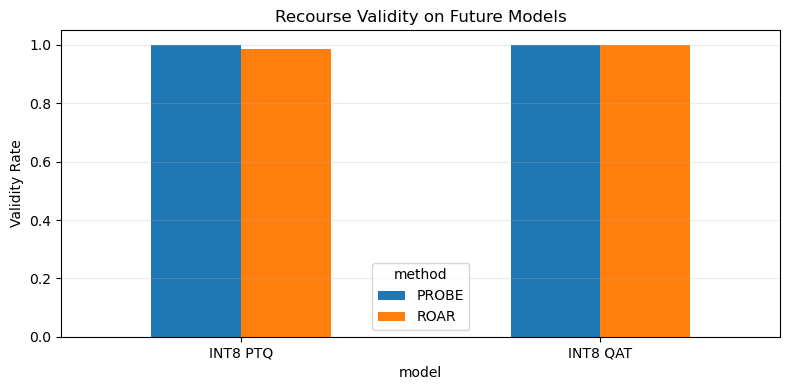

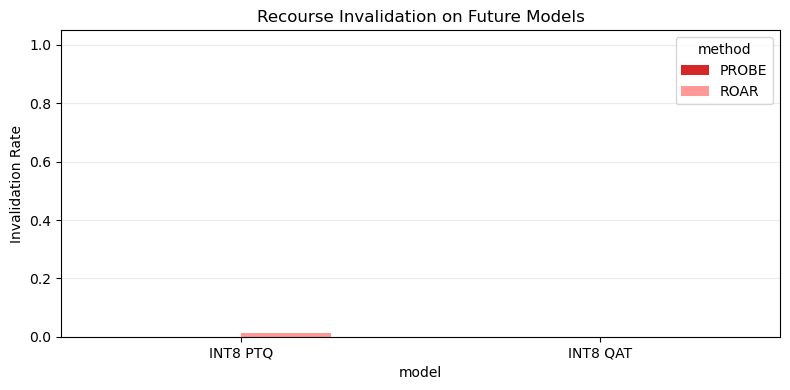

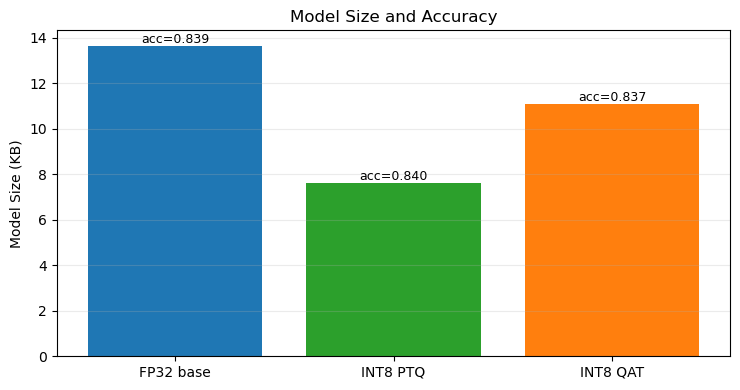

In [ ]:
# Final comparison: PROBE vs ROAR transfer + model performance visuals


probe_cmp = recourse_summary.copy()
probe_cmp["method"] = "PROBE"
roar_cmp = roar_recourse_summary.copy()
roar_cmp["method"] = "ROAR"

comparison_df = pd.concat([probe_cmp, roar_cmp], ignore_index=True)
comparison_df["recourse_invalidation_rate"] = comparison_df["recourse_invalidation_rate"].fillna(
    1.0 - comparison_df["recourse_validity_rate"]
)

print("Combined transfer comparison table")
display(
    comparison_df[[
        "method",
        "model",
        "recourse_validity_rate",
        "recourse_invalidation_rate",
        "delta_vs_base",
    ]].sort_values(["method", "model"]).reset_index(drop=True)
 )

# Plot 1: Validity rates by method and future model
future_only = comparison_df[comparison_df["model"] != "FP32 base"].copy()
if len(future_only) > 0:
    pivot_valid = future_only.pivot(index="model", columns="method", values="recourse_validity_rate")
    ax = pivot_valid.plot(kind="bar", figsize=(8, 4), rot=0)
    ax.set_title("Recourse Validity on Future Models")
    ax.set_ylabel("Validity Rate")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

# Plot 2: Invalidation rates by method and future model
if len(future_only) > 0:
    pivot_inv = future_only.pivot(index="model", columns="method", values="recourse_invalidation_rate")
    ax = pivot_inv.plot(kind="bar", figsize=(8, 4), rot=0, color=["#d62728", "#ff9896"])
    ax.set_title("Recourse Invalidation on Future Models")
    ax.set_ylabel("Invalidation Rate")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

# Plot 3: Model compression-performance tradeoff
perf_plot_df = model_table[["model", "test_acc", "size_kb"]].copy()
fig, ax = plt.subplots(figsize=(7.5, 4))
bars = ax.bar(perf_plot_df["model"], perf_plot_df["size_kb"], color=["#1f77b4", "#2ca02c", "#ff7f0e"][:len(perf_plot_df)])
ax.set_title("Model Size and Accuracy")
ax.set_ylabel("Model Size (KB)")
ax.grid(axis="y", alpha=0.25)

for bar, acc in zip(bars, perf_plot_df["test_acc"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height(),
        f"acc={acc:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

In [14]:
# ===== New Section: Quantized Base (German) -> FP32 Future (German Corrected) =====
GERMAN_BASE_PATH = "data/german.csv"
GERMAN_FUTURE_PATH = "data/german_corrected.csv"
GERMAN_TARGET = "credit_risk"
GERMAN_BRANCH_EPOCHS = 25
GERMAN_QAT_FINETUNE_EPOCHS = 10
GERMAN_REC_N_SAMPLES = 80

def preprocess_german_pair(base_path, future_path, target_col):
    df_base = pd.read_csv(base_path)
    df_future = pd.read_csv(future_path)

    num_feat = ["duration", "amount", "age"]
    cat_feat = ["personal_status_sex"]
    target  = target_col

    current = df_base.drop(columns=[c for c in list(df_base) if c not in num_feat+cat_feat+[target]])
    future = df_future.drop(columns=[c for c in list(df_future) if c not in num_feat+cat_feat+[target]])

    for key in num_feat:
        scaler = StandardScaler()
        current[key] = scaler.fit_transform(current[key].values.reshape(-1,1))
        future[key] = scaler.transform(future[key].values.reshape(-1,1))

    Xc, yc = current.drop(columns=[target]), current[target]
    Xf, yf = future.drop(columns=[target]), future[target]

    Xb_train, Xb_test, yb_train, yb_test = train_test_split(
        Xc, yc, test_size=0.20, random_state=SEED, stratify=yc
    )
    Xf_train, Xf_test, yf_train, yf_test = train_test_split(
        Xf, yf, test_size=0.20, random_state=SEED, stratify=yf
    )

    return {
        "Xb_train": Xb_train,
        "Xb_test": Xb_test,
        "yb_train": yb_train,
        "yb_test": yb_test,
        "Xf_train": Xf_train,
        "Xf_test": Xf_test,
        "yf_train": yf_train,
        "yf_test": yf_test,
        "feature_min": Xb_train.min(axis=0).to_numpy(dtype=np.float32),
        "feature_max": Xb_train.max(axis=0).to_numpy(dtype=np.float32),
    }

gpair = preprocess_german_pair(GERMAN_BASE_PATH, GERMAN_FUTURE_PATH, GERMAN_TARGET)

Xb_train_t = torch.tensor(gpair["Xb_train"].to_numpy(), dtype=torch.float32)
yb_train_t = torch.tensor(gpair["yb_train"].to_numpy(), dtype=torch.float32)
Xb_test_t = torch.tensor(gpair["Xb_test"].to_numpy(), dtype=torch.float32)
yb_test_t = torch.tensor(gpair["yb_test"].to_numpy(), dtype=torch.float32)
Xf_train_t = torch.tensor(gpair["Xf_train"].to_numpy(), dtype=torch.float32)
yf_train_t = torch.tensor(gpair["yf_train"].to_numpy(), dtype=torch.float32)
Xf_test_t = torch.tensor(gpair["Xf_test"].to_numpy(), dtype=torch.float32)
yf_test_t = torch.tensor(gpair["yf_test"].to_numpy(), dtype=torch.float32)

german_input_dim = Xb_train_t.shape[1]
gbase_loader = DataLoader(TensorDataset(Xb_train_t, yb_train_t), batch_size=BATCH_SIZE, shuffle=True)
gfuture_loader = DataLoader(TensorDataset(Xf_train_t, yf_train_t), batch_size=BATCH_SIZE, shuffle=True)

print(f"German aligned input_dim: {german_input_dim}")
print(f"Base train/test: {Xb_train_t.shape} / {Xb_test_t.shape}")
print(f"Future train/test: {Xf_train_t.shape} / {Xf_test_t.shape}")

German aligned input_dim: 4
Base train/test: torch.Size([800, 4]) / torch.Size([200, 4])
Future train/test: torch.Size([800, 4]) / torch.Size([200, 4])


In [15]:
# Train old-data FP32 source, quantize to PTQ/QAT base models, and train corrected-data FP32 future
ger_source_fp32 = MLPBinary(input_dim=german_input_dim)
ger_source_fp32 = train_model(
    ger_source_fp32, gbase_loader, Xb_test_t, yb_test_t, epochs=GERMAN_BRANCH_EPOCHS, lr=LR
)

ger_ptq_model = quantize_dynamic(copy.deepcopy(ger_source_fp32).eval(), {nn.Linear}, dtype=torch.qint8)

ger_qat_float = QuantizableMLPBinary(input_dim=german_input_dim)
ger_qat_float.load_state_dict(copy.deepcopy(ger_source_fp32).state_dict(), strict=True)
ger_qat_float.fuse_model()
ger_qat_float.qconfig = get_default_qat_qconfig("fbgemm")
prepare_qat(ger_qat_float, inplace=True)
ger_qat_opt = optim.Adam(ger_qat_float.parameters(), lr=LR * 0.5)
ger_qat_criterion = nn.BCELoss()
ger_qat_float.train()
for epoch in range(GERMAN_QAT_FINETUNE_EPOCHS):
    for xb, yb in gbase_loader:
        ger_qat_opt.zero_grad()
        probs_1 = ger_qat_float(xb)[:, 1]
        loss = ger_qat_criterion(probs_1, yb)
        loss.backward()
        ger_qat_opt.step()
ger_qat_float.eval()
ger_qat_model = copy.deepcopy(ger_qat_float)
convert(ger_qat_model, inplace=True)

ger_future_fp32 = MLPBinary(input_dim=german_input_dim)
ger_future_fp32 = train_model(
    ger_future_fp32, gfuture_loader, Xf_test_t, yf_test_t, epochs=GERMAN_BRANCH_EPOCHS, lr=LR
)

ger_eval = nn.BCELoss()
ger_perf = pd.DataFrame([
    {
        "model": "German base FP32 source",
        "acc": evaluate_model(ger_source_fp32, Xb_test_t, yb_test_t, ger_eval).accuracy,
        "auc": evaluate_model(ger_source_fp32, Xb_test_t, yb_test_t, ger_eval).auroc,
    },
    {
        "model": "German base INT8 PTQ",
        "acc": evaluate_model(ger_ptq_model, Xb_test_t, yb_test_t, ger_eval).accuracy,
        "auc": evaluate_model(ger_ptq_model, Xb_test_t, yb_test_t, ger_eval).auroc,
    },
    {
        "model": "German base INT8 QAT",
        "acc": evaluate_model(ger_qat_model, Xb_test_t, yb_test_t, ger_eval).accuracy,
        "auc": evaluate_model(ger_qat_model, Xb_test_t, yb_test_t, ger_eval).auroc,
    },
    {
        "model": "German future FP32 (corrected)",
        "acc": evaluate_model(ger_future_fp32, Xf_test_t, yf_test_t, ger_eval).accuracy,
        "auc": evaluate_model(ger_future_fp32, Xf_test_t, yf_test_t, ger_eval).auroc,
    },
] )
display(ger_perf)

Epoch  5/25 | val_loss=0.5682 | val_acc=68.50% | val_auc=0.7005
Epoch 10/25 | val_loss=0.5664 | val_acc=70.00% | val_auc=0.6926
Epoch 15/25 | val_loss=0.5635 | val_acc=70.50% | val_auc=0.6976
Epoch 20/25 | val_loss=0.5595 | val_acc=72.50% | val_auc=0.7058
Epoch 25/25 | val_loss=0.5590 | val_acc=73.50% | val_auc=0.7087
Epoch  5/25 | val_loss=0.5750 | val_acc=71.00% | val_auc=0.6755
Epoch 10/25 | val_loss=0.5616 | val_acc=71.50% | val_auc=0.6993
Epoch 15/25 | val_loss=0.5566 | val_acc=71.00% | val_auc=0.7114
Epoch 20/25 | val_loss=0.5534 | val_acc=72.00% | val_auc=0.7170
Epoch 25/25 | val_loss=0.5506 | val_acc=72.50% | val_auc=0.7254


,model,acc,auc
0,German base FP32 source,0.735,0.708690
1,German base INT8 PTQ,0.730,0.708393
2,German base INT8 QAT,0.745,0.706786
3,German future FP32 (corrected),0.725,0.725357


In [37]:
# Simple Wachter-style CF search for quantized-base models (L1 nearest), with gradient surrogate
def _sigmoid_prob(model, x_np):
    xt = torch.tensor(x_np, dtype=torch.float32).reshape(1, -1)
    with torch.no_grad():
        return model(xt)[:, 1].item()

def wachter_cf_quantized_base(
    quant_model,
    surrogate_model,
    x0_np,
    feature_min,
    feature_max,
    lr=0.03,
    lambda_param=0.02,
    n_iter=800,
    threshold=0.5,
 ):
    surrogate_model.eval()
    quant_model.eval()

    x0 = torch.tensor(x0_np, dtype=torch.float32).reshape(1, -1)
    xmin = torch.tensor(feature_min, dtype=torch.float32).reshape(1, -1)
    xmax = torch.tensor(feature_max, dtype=torch.float32).reshape(1, -1)
    x_cf = x0.clone().detach().requires_grad_(True)
    opt = optim.Adam([x_cf], lr=lr)
    target = torch.ones(1, dtype=torch.float32)

    best = None
    best_cost = float("inf")
    best_quant_prob = 0.0

    for _ in range(n_iter):
        opt.zero_grad()
        p_sur = surrogate_model(x_cf)[:, 1]
        clf_loss = nn.BCELoss()(p_sur, target)
        l1 = torch.norm(x_cf - x0, p=1)
        loss = clf_loss + lambda_param * l1
        loss.backward()
        opt.step()

        with torch.no_grad():
            x_cf.clamp_(xmin, xmax)
            p_quant = quant_model(x_cf)[:, 1].item()
            if p_quant >= threshold:
                cost = torch.norm(x_cf - x0, p=1).item()
                if cost < best_cost:
                    best_cost = cost
                    best = x_cf.detach().clone()
                    best_quant_prob = p_quant

    if best is None:
        best = x_cf.detach().clone()
        best_quant_prob = quant_model(best)[:, 1].item()

    out = best.cpu().numpy().reshape(-1)
    meta = {
        "quant_prob_cf": float(best_quant_prob),
        "l1_cost": float(np.linalg.norm(out - x0_np, ord=1)),
    }
    return out, meta

def run_quantized_base_generation(
    quant_model,
    surrogate_model,
    X_test_df,
    feature_min,
    feature_max,
    n_samples,
    tag,
 ):
    with torch.no_grad():
        probs = quant_model(torch.tensor(X_test_df.to_numpy(), dtype=torch.float32))[:, 1].numpy()
    neg_idx = np.where(probs < DECISION_THRESHOLD)[0]
    chosen = neg_idx[: min(n_samples, len(neg_idx))]

    rows = []
    for idx in chosen:
        x0 = X_test_df.iloc[idx].to_numpy(dtype=np.float32)
        x_cf, meta = wachter_cf_quantized_base(
            quant_model,
            surrogate_model,
            x0,
            feature_min,
            feature_max,
            lr=0.03,
            lambda_param=0.02,
            n_iter=800,
            threshold=DECISION_THRESHOLD,
        )
        rows.append({
            "method": tag,
            "idx": int(idx),
            "x0": x0,
            "xcf": x_cf,
            "base_quant_prob_cf": meta["quant_prob_cf"],
            "l1_cost": meta["l1_cost"],
            "base_quant_valid": float(meta["quant_prob_cf"] >= DECISION_THRESHOLD),
        })
    return rows

ptq_generated_german = run_quantized_base_generation(
    ger_ptq_model,
    ger_source_fp32,
    gpair["Xb_test"],
    gpair["feature_min"],
    gpair["feature_max"],
    GERMAN_REC_N_SAMPLES,
    "PTQ->FP32_future",
)
qat_generated_german = run_quantized_base_generation(
    ger_qat_model,
    ger_source_fp32,
    gpair["Xb_test"],
    gpair["feature_min"],
    gpair["feature_max"],
    GERMAN_REC_N_SAMPLES,
    "QAT->FP32_future",
)

print(f"German PTQ CF generated: {len(ptq_generated_german)}")
print(f"German QAT CF generated: {len(qat_generated_german)}")

German PTQ CF generated: 20
German QAT CF generated: 17


In [38]:
# Evaluate quantized-base generated CFs on future FP32 corrected model
def evaluate_generated_on_future(generated_rows, future_model):
    out = []
    for item in generated_rows:
        xcf = item["xcf"]
        with torch.no_grad():
            p_future = future_model(torch.tensor(xcf, dtype=torch.float32).reshape(1, -1))[:, 1].item()
        rec = {**item}
        rec["future_fp32_prob_cf"] = p_future
        rec["future_fp32_valid"] = float(p_future >= DECISION_THRESHOLD)
        rec["invalid_on_future"] = float((item["base_quant_valid"] == 1.0) and (p_future < DECISION_THRESHOLD))
        rec["prob_shift_future_minus_base"] = p_future - item["base_quant_prob_cf"]
        out.append(rec)
    return pd.DataFrame(out)

ptq_future_eval_df = evaluate_generated_on_future(ptq_generated_german, ger_future_fp32)
qat_future_eval_df = evaluate_generated_on_future(qat_generated_german, ger_future_fp32)
german_transfer_df = pd.concat([ptq_future_eval_df, qat_future_eval_df], ignore_index=True)

summary_rows = []
for tag, sub in german_transfer_df.groupby("method"):
    summary_rows.append(
        {
            "method": tag,
            "n_generated": len(sub),
            "base_quant_valid_rate": sub["base_quant_valid"].mean(),
            "future_fp32_valid_rate": sub["future_fp32_valid"].mean(),
            "future_invalidation_rate": 1.0 - sub["future_fp32_valid"].mean(),
            "invalid_on_future_rate": sub["invalid_on_future"].mean(),
            "mean_l1_cost": sub["l1_cost"].mean(),
            "mean_prob_shift": sub["prob_shift_future_minus_base"].mean(),
        }
    )

german_transfer_summary = pd.DataFrame(summary_rows)
print("German cross-dataset transfer summary: quantized base -> FP32 future")
display(german_transfer_summary)

print("Invalid-on-future examples (valid on quantized base but invalid on future FP32):")
display(
    german_transfer_df[german_transfer_df["invalid_on_future"] == 1.0][
        ["method", "idx", "base_quant_prob_cf", "future_fp32_prob_cf", "l1_cost", "prob_shift_future_minus_base"]
    ].head(20)
)

German cross-dataset transfer summary: quantized base -> FP32 future


,method,n_generated,base_quant_valid_rate,future_fp32_valid_rate,future_invalidation_rate,invalid_on_future_rate,mean_l1_cost,mean_prob_shift
0,PTQ->FP32_future,20,1.0,0.950000,0.050000,0.050000,1.680999,0.089731
1,QAT->FP32_future,17,1.0,0.941176,0.058824,0.058824,1.718186,0.076413


Invalid-on-future examples (valid on quantized base but invalid on future FP32):


,method,idx,base_quant_prob_cf,future_fp32_prob_cf,l1_cost,prob_shift_future_minus_base
19,PTQ->FP32_future,189,0.510288,0.471656,1.435817,-0.038632
36,QAT->FP32_future,189,0.519531,0.456702,1.318103,-0.062829


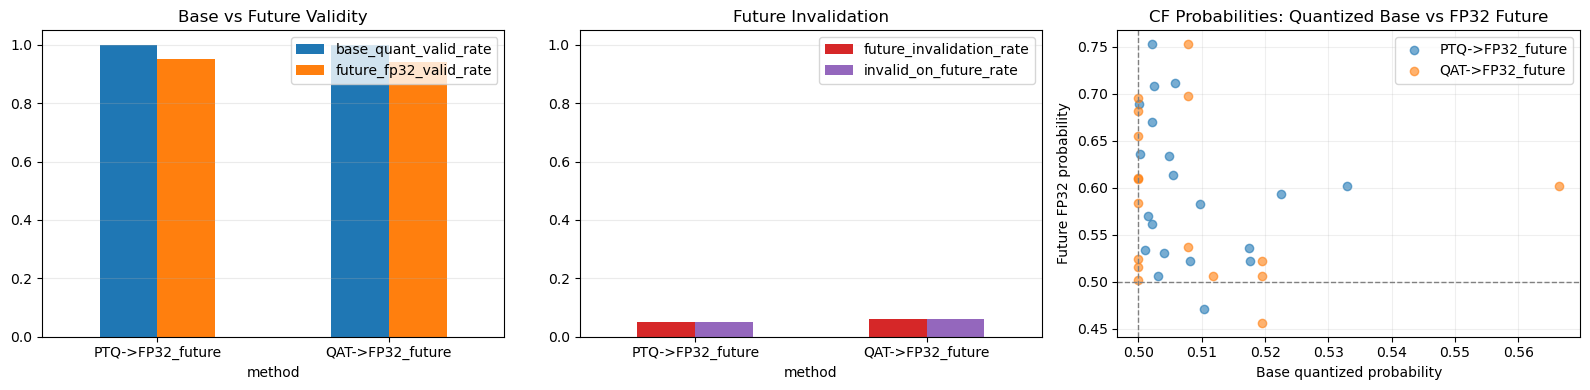

In [41]:
# Visualize PTQ vs QAT transfer under the German cross-dataset setup
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

plot_df = german_transfer_summary.set_index("method")
plot_df[["base_quant_valid_rate", "future_fp32_valid_rate"]].plot(kind="bar", ax=axes[0], rot=0)
axes[0].set_title("Base vs Future Validity")
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis="y", alpha=0.25)

plot_df[["future_invalidation_rate", "invalid_on_future_rate"]].plot(kind="bar", ax=axes[1], rot=0, color=["#d62728", "#9467bd"])
axes[1].set_title("Future Invalidation")
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis="y", alpha=0.25)

for method_name, sub in german_transfer_df.groupby("method"):
    axes[2].scatter(
        sub["base_quant_prob_cf"],
        sub["future_fp32_prob_cf"],
        alpha=0.6,
        label=method_name,
    )
axes[2].axvline(DECISION_THRESHOLD, linestyle="--", color="gray", linewidth=1)
axes[2].axhline(DECISION_THRESHOLD, linestyle="--", color="gray", linewidth=1)
axes[2].set_title("CF Probabilities: Quantized Base vs FP32 Future")
axes[2].set_xlabel("Base quantized probability")
axes[2].set_ylabel("Future FP32 probability")
axes[2].legend()
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.show()

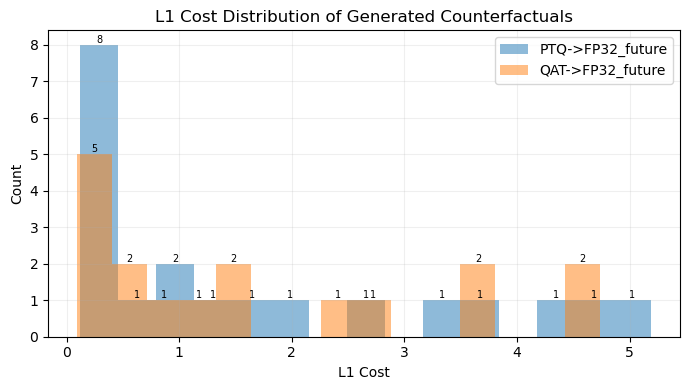

In [42]:
plt.figure(figsize=(7, 4))
for method_name, sub in german_transfer_df.groupby("method"):
    counts, bins, patches = plt.hist(sub["l1_cost"], bins=15, alpha=0.5, label=method_name)
    for count, patch in zip(counts, patches):
        if count > 0:
            x = patch.get_x() + patch.get_width() / 2.0
            y = patch.get_height()
            plt.text(x, y, f"{int(count)}", ha="center", va="bottom", fontsize=7)
plt.title("L1 Cost Distribution of Generated Counterfactuals")
plt.xlabel("L1 Cost")
plt.ylabel("Count")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [44]:
# ===== SBA Current -> Future: Quantized Base -> FP32 Future =====
SBA_PATH = "data/SBAcase.11.13.17.csv"
SBA_BRANCH_EPOCHS = 20
SBA_QAT_FINETUNE_EPOCHS = 8
SBA_REC_N_SAMPLES = 80

SBA_DROP_COLS = [
    "Selected",
    "State",
    "Name",
    "BalanceGross",
    "LowDoc",
    "BankState",
    "LoanNr_ChkDgt",
    "MIS_Status",
    "Default",
    "Bank",
    "City",
]

def preprocess_sba_current_future(path):
    df_raw = pd.read_csv(path, low_memory=False)
    default_raw = pd.to_numeric(df_raw["Default"], errors="coerce").fillna(0)
    default_bin = (default_raw > 0).astype(int)
    df_raw["NoDefault"] = 1 - default_bin.values

    keep_drop = [c for c in SBA_DROP_COLS if c in df_raw.columns]
    df = df_raw.drop(columns=keep_drop).copy()

    cat_feat = df.select_dtypes(include=["object"]).columns.tolist()
    num_feat = df.drop(columns=["NoDefault"]).select_dtypes(exclude=["object"]).columns.tolist()

    df = pd.get_dummies(df, columns=cat_feat)

    current = df[df["ApprovalFY"] < 2006].copy()
    future = df.copy()

    for key in num_feat:
        scaler = StandardScaler()
        current[key] = scaler.fit_transform(current[key].values.reshape(-1, 1))
        future[key] = scaler.transform(future[key].values.reshape(-1, 1))

    Xc, yc = current.drop(columns=["NoDefault"]), current["NoDefault"]
    Xf, yf = future.drop(columns=["NoDefault"]), future["NoDefault"]

    Xc = Xc.apply(pd.to_numeric, errors="coerce").fillna(0.0).astype(np.float32)
    Xf = Xf.apply(pd.to_numeric, errors="coerce").fillna(0.0).astype(np.float32)
    yc = yc.astype(np.float32).clip(0, 1)
    yf = yf.astype(np.float32).clip(0, 1)

    Xc_train, Xc_test, yc_train, yc_test = train_test_split(
        Xc, yc, test_size=0.20, random_state=SEED, stratify=yc
    )
    Xf_train, Xf_test, yf_train, yf_test = train_test_split(
        Xf, yf, test_size=0.20, random_state=SEED, stratify=yf
    )

    return {
        "Xc_train": Xc_train,
        "Xc_test": Xc_test,
        "yc_train": yc_train,
        "yc_test": yc_test,
        "Xf_train": Xf_train,
        "Xf_test": Xf_test,
        "yf_train": yf_train,
        "yf_test": yf_test,
        "feature_min": Xc_train.min(axis=0).to_numpy(dtype=np.float32),
        "feature_max": Xc_train.max(axis=0).to_numpy(dtype=np.float32),
    }

sbapair = preprocess_sba_current_future(SBA_PATH)
print(f"SBA current train/test: {sbapair['Xc_train'].shape} / {sbapair['Xc_test'].shape}")
print(f"SBA future train/test: {sbapair['Xf_train'].shape} / {sbapair['Xf_test'].shape}")

SBA current train/test: (927, 27) / (232, 27)
SBA future train/test: (1681, 27) / (421, 27)


In [45]:
# Train SBA current-source models and SBA future FP32 model
Xc_train_t = torch.tensor(sbapair["Xc_train"].to_numpy(), dtype=torch.float32)
yc_train_t = torch.tensor(sbapair["yc_train"].to_numpy(), dtype=torch.float32)
Xc_test_t = torch.tensor(sbapair["Xc_test"].to_numpy(), dtype=torch.float32)
yc_test_t = torch.tensor(sbapair["yc_test"].to_numpy(), dtype=torch.float32)
Xf_train_t = torch.tensor(sbapair["Xf_train"].to_numpy(), dtype=torch.float32)
yf_train_t = torch.tensor(sbapair["yf_train"].to_numpy(), dtype=torch.float32)
Xf_test_t = torch.tensor(sbapair["Xf_test"].to_numpy(), dtype=torch.float32)
yf_test_t = torch.tensor(sbapair["yf_test"].to_numpy(), dtype=torch.float32)

sba_input_dim = Xc_train_t.shape[1]
sba_current_loader = DataLoader(TensorDataset(Xc_train_t, yc_train_t), batch_size=BATCH_SIZE, shuffle=True)
sba_future_loader = DataLoader(TensorDataset(Xf_train_t, yf_train_t), batch_size=BATCH_SIZE, shuffle=True)

sba_source_fp32 = MLPBinary(input_dim=sba_input_dim)
sba_source_fp32 = train_model(
    sba_source_fp32, sba_current_loader, Xc_test_t, yc_test_t, epochs=SBA_BRANCH_EPOCHS, lr=LR
)

sba_ptq_model = quantize_dynamic(copy.deepcopy(sba_source_fp32).eval(), {nn.Linear}, dtype=torch.qint8)

sba_qat_float = QuantizableMLPBinary(input_dim=sba_input_dim)
sba_qat_float.load_state_dict(copy.deepcopy(sba_source_fp32).state_dict(), strict=True)
sba_qat_float.fuse_model()
sba_qat_float.qconfig = get_default_qat_qconfig("fbgemm")
prepare_qat(sba_qat_float, inplace=True)
sba_qat_opt = optim.Adam(sba_qat_float.parameters(), lr=LR * 0.5)
sba_qat_criterion = nn.BCELoss()
sba_qat_float.train()
for _ in range(SBA_QAT_FINETUNE_EPOCHS):
    for xb, yb in sba_current_loader:
        sba_qat_opt.zero_grad()
        probs_1 = sba_qat_float(xb)[:, 1]
        loss = sba_qat_criterion(probs_1, yb)
        loss.backward()
        sba_qat_opt.step()
sba_qat_float.eval()
sba_qat_model = copy.deepcopy(sba_qat_float)
convert(sba_qat_model, inplace=True)

sba_future_fp32 = MLPBinary(input_dim=sba_input_dim)
sba_future_fp32 = train_model(
    sba_future_fp32, sba_future_loader, Xf_test_t, yf_test_t, epochs=SBA_BRANCH_EPOCHS, lr=LR
)

sba_eval = nn.BCELoss()
sba_perf = pd.DataFrame([
    {
        "model": "SBA current FP32 source",
        "acc": evaluate_model(sba_source_fp32, Xc_test_t, yc_test_t, sba_eval).accuracy,
        "auc": evaluate_model(sba_source_fp32, Xc_test_t, yc_test_t, sba_eval).auroc,
    },
    {
        "model": "SBA current INT8 PTQ",
        "acc": evaluate_model(sba_ptq_model, Xc_test_t, yc_test_t, sba_eval).accuracy,
        "auc": evaluate_model(sba_ptq_model, Xc_test_t, yc_test_t, sba_eval).auroc,
    },
    {
        "model": "SBA current INT8 QAT",
        "acc": evaluate_model(sba_qat_model, Xc_test_t, yc_test_t, sba_eval).accuracy,
        "auc": evaluate_model(sba_qat_model, Xc_test_t, yc_test_t, sba_eval).auroc,
    },
    {
        "model": "SBA future FP32",
        "acc": evaluate_model(sba_future_fp32, Xf_test_t, yf_test_t, sba_eval).accuracy,
        "auc": evaluate_model(sba_future_fp32, Xf_test_t, yf_test_t, sba_eval).auroc,
    },
])
display(sba_perf)

Epoch  5/20 | val_loss=0.2865 | val_acc=85.34% | val_auc=0.9131
Epoch 10/20 | val_loss=0.1622 | val_acc=94.40% | val_auc=0.9641
Epoch 15/20 | val_loss=0.1181 | val_acc=96.55% | val_auc=0.9788
Epoch 20/20 | val_loss=0.1100 | val_acc=96.55% | val_auc=0.9800
Epoch  5/20 | val_loss=0.1612 | val_acc=96.20% | val_auc=0.9825
Epoch 10/20 | val_loss=0.1121 | val_acc=95.96% | val_auc=0.9867
Epoch 15/20 | val_loss=0.1057 | val_acc=96.44% | val_auc=0.9875
Epoch 20/20 | val_loss=0.1077 | val_acc=96.67% | val_auc=0.9859


,model,acc,auc
0,SBA current FP32 source,0.965517,0.980042
1,SBA current INT8 PTQ,0.965517,0.979487
2,SBA current INT8 QAT,0.974138,0.980249
3,SBA future FP32,0.966746,0.985915


In [46]:
# Generate recourse on SBA quantized bases and evaluate on SBA future FP32
sba_ptq_generated = run_quantized_base_generation(
    sba_ptq_model,
    sba_source_fp32,
    sbapair["Xc_test"],
    sbapair["feature_min"],
    sbapair["feature_max"],
    SBA_REC_N_SAMPLES,
    "PTQ->FP32_future_SBA",
)
sba_qat_generated = run_quantized_base_generation(
    sba_qat_model,
    sba_source_fp32,
    sbapair["Xc_test"],
    sbapair["feature_min"],
    sbapair["feature_max"],
    SBA_REC_N_SAMPLES,
    "QAT->FP32_future_SBA",
)

sba_ptq_eval_df = evaluate_generated_on_future(sba_ptq_generated, sba_future_fp32)
sba_qat_eval_df = evaluate_generated_on_future(sba_qat_generated, sba_future_fp32)
sba_transfer_df = pd.concat([sba_ptq_eval_df, sba_qat_eval_df], ignore_index=True)

sba_summary_rows = []
for tag, sub in sba_transfer_df.groupby("method"):
    sba_summary_rows.append(
        {
            "method": tag,
            "n_generated": len(sub),
            "base_quant_valid_rate": sub["base_quant_valid"].mean(),
            "future_fp32_valid_rate": sub["future_fp32_valid"].mean(),
            "future_invalidation_rate": 1.0 - sub["future_fp32_valid"].mean(),
            "invalid_on_future_rate": sub["invalid_on_future"].mean(),
            "mean_l1_cost": sub["l1_cost"].mean(),
            "mean_prob_shift": sub["prob_shift_future_minus_base"].mean(),
        }
    )

sba_transfer_summary = pd.DataFrame(sba_summary_rows)
print("SBA current->future transfer summary: quantized base -> FP32 future")
display(sba_transfer_summary)

print("SBA invalid-on-future examples")
display(
    sba_transfer_df[sba_transfer_df["invalid_on_future"] == 1.0][
        ["method", "idx", "base_quant_prob_cf", "future_fp32_prob_cf", "l1_cost", "prob_shift_future_minus_base"]
    ].head(20)
)

SBA current->future transfer summary: quantized base -> FP32 future


,method,n_generated,base_quant_valid_rate,future_fp32_valid_rate,future_invalidation_rate,invalid_on_future_rate,mean_l1_cost,mean_prob_shift
0,PTQ->FP32_future_SBA,33,1.0,0.787879,0.212121,0.212121,3.614827,-0.167737
1,QAT->FP32_future_SBA,35,1.0,0.685714,0.314286,0.314286,3.411972,-0.204686


SBA invalid-on-future examples


,method,idx,base_quant_prob_cf,future_fp32_prob_cf,l1_cost,prob_shift_future_minus_base
2,PTQ->FP32_future_SBA,39,0.993830,2.291775e-03,2.698334,-0.991538
4,PTQ->FP32_future_SBA,51,0.979013,2.420872e-04,12.171702,-0.978771
7,PTQ->FP32_future_SBA,109,0.974996,3.783580e-09,23.463202,-0.974996
8,PTQ->FP32_future_SBA,114,0.659442,3.876180e-01,1.774444,-0.271824
11,PTQ->FP32_future_SBA,119,0.975211,2.788996e-04,11.714838,-0.974932
28,PTQ->FP32_future_SBA,201,0.658974,2.248041e-01,0.593469,-0.434169
30,PTQ->FP32_future_SBA,225,0.543157,1.019164e-02,0.616937,-0.532966
33,QAT->FP32_future_SBA,3,0.628906,7.023010e-02,0.600000,-0.558676
36,QAT->FP32_future_SBA,39,0.992188,2.291775e-03,2.698334,-0.989896
38,QAT->FP32_future_SBA,51,0.968750,2.420872e-04,12.171702,-0.968508


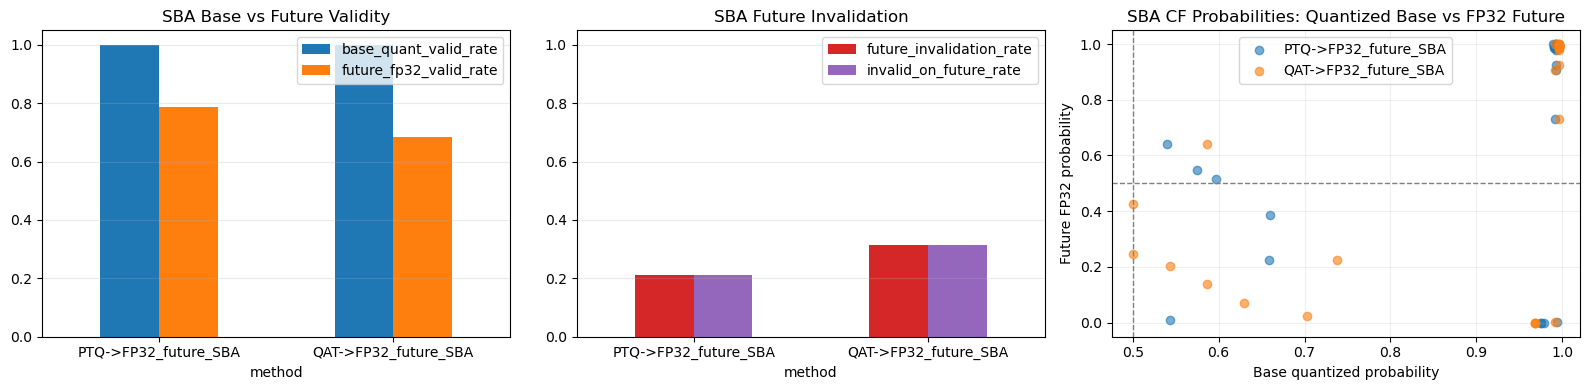

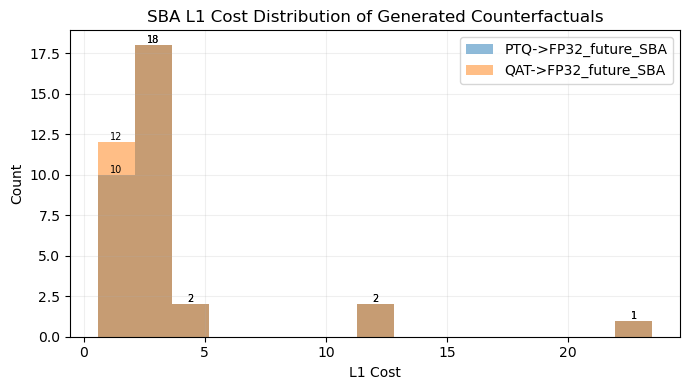

In [47]:
# SBA plots: validity, invalidation, probability shift, and labeled L1 histogram
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sba_plot_df = sba_transfer_summary.set_index("method")
sba_plot_df[["base_quant_valid_rate", "future_fp32_valid_rate"]].plot(kind="bar", ax=axes[0], rot=0)
axes[0].set_title("SBA Base vs Future Validity")
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis="y", alpha=0.25)

sba_plot_df[["future_invalidation_rate", "invalid_on_future_rate"]].plot(kind="bar", ax=axes[1], rot=0, color=["#d62728", "#9467bd"])
axes[1].set_title("SBA Future Invalidation")
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis="y", alpha=0.25)

for method_name, sub in sba_transfer_df.groupby("method"):
    axes[2].scatter(sub["base_quant_prob_cf"], sub["future_fp32_prob_cf"], alpha=0.6, label=method_name)
axes[2].axvline(DECISION_THRESHOLD, linestyle="--", color="gray", linewidth=1)
axes[2].axhline(DECISION_THRESHOLD, linestyle="--", color="gray", linewidth=1)
axes[2].set_title("SBA CF Probabilities: Quantized Base vs FP32 Future")
axes[2].set_xlabel("Base quantized probability")
axes[2].set_ylabel("Future FP32 probability")
axes[2].legend()
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
for method_name, sub in sba_transfer_df.groupby("method"):
    counts, bins, patches = plt.hist(sub["l1_cost"], bins=15, alpha=0.5, label=method_name)
    for count, patch in zip(counts, patches):
        if count > 0:
            x = patch.get_x() + patch.get_width() / 2.0
            y = patch.get_height()
            plt.text(x, y, f"{int(count)}", ha="center", va="bottom", fontsize=7)
plt.title("SBA L1 Cost Distribution of Generated Counterfactuals")
plt.xlabel("L1 Cost")
plt.ylabel("Count")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()